# HITL_interrupt_command_Agent

In [ ]:
from dotenv import load_dotenv
import os
from langgraph.constants import START, END
from pymongo import MongoClient
from langgraph.checkpoint.mongodb import MongoDBSaver
from langchain_core.tools import tool
load_dotenv(".env")


client = MongoClient(host=os.getenv("MONGO_HOST"),
                     port=int(os.getenv("MONGO_PORT")),
                     username=os.getenv("MONGO_USER"),
                     password=os.getenv("MONGO_PASSWORD"))
memory = MongoDBSaver(client)
from langchain_deepseek import ChatDeepSeek

## 构建模型
model = ChatDeepSeek(model="deepseek-chat", 
                     api_key=os.getenv("DEEPSEEK_API_KEY"),
                     base_url=os.getenv("DEEPSEEK_API_BASE"))

/opt/anaconda3/envs/llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
FORBIDDEN_TOPICS = ["violence", "murder", "sex", "drugs", "death", "blood", "war"]

@tool
def fetch_story(topic: str) -> str:
    """返回基于给定主题的短篇故事。

    Args:
        topic (str): 主题。

    Returns:
        str: 基于主题的短篇故事。
    """    
    stories = {
        "sharing": "兔子本尼分享了他的胡萝卜，让大家都很开心！",
        "kindness": "莱拉帮助了一位老人，并成立了一个爱心俱乐部!",
        "honesty": "奥马尔承认了自己的错误，并变得值得信赖。",
        "violence": "勇士们浴血奋战......（🚫 少儿不宜！）。"
    }
    return stories.get(topic.lower(), "对不起，此主题暂无相关报道。")

In [4]:
model = model.bind_tools([fetch_story])


In [5]:
from langchain_core.messages import AIMessage
def moderate_topic_node(state):
    question = state["messages"][-1].content
    prompt = (
        f"如果下面的问题与这些主题中的任何一个相关，则返回 `True`："
        f"{', '.join(FORBIDDEN_TOPICS)}. 否则返回`False`.\n\问题: {question}"
    )
    result = model.invoke(prompt).content.strip().lower()
    return {"messages": state["messages"] + [AIMessage(content=result)]}

In [6]:
def route_after_moderation(state):
    result = state["messages"][-1].content.strip().lower()
    if "True" in result:
        return "reject_story_node"
    return "generate_story"


def generate_story(state):
    messages = state["messages"]
    response = model.invoke(messages)
    return {"messages": response}

def should_continue(state):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "call_tool"
    return "human_review_node"

def route_after_tool(state):
    story = state["messages"][-1].content.lower()
    if any(word in story for word in FORBIDDEN_TOPICS):
        return "reject_story_node"
    return "human_review_node"


def reject_story_node(state):
    if state["messages"][-1].content == "Story rejected by human":
        return {
            "messages": ["❌ "] + [state["messages"][-1]]
        }
    else:
        return {
            "messages": [
                AIMessage(content="❌ 该主题不适合儿童，已被拒绝。")
            ]
        }


from langgraph.types import Command, interrupt

def human_review_node(state):
    last_message = state["messages"][-1]
    review = interrupt({
        "question": "你想发表这个故事吗？",
        "story": last_message
    })

    action = review["action"]
    data = review.get("data")
    if action == "publish":
        print("published!")
        return Command(goto=END)
    elif action == "reject":
        return Command(goto=END, update={
            "messages": state["messages"] + [AIMessage(content="❌ Story rejected by human.")]
        })


In [7]:
from langgraph.graph import StateGraph, MessagesState, END
from langgraph.prebuilt import ToolNode

builder = StateGraph(MessagesState)

tools = ToolNode(tools=[fetch_story])

builder.add_node("moderate_topic", moderate_topic_node)
builder.add_node("call_tool", tools)
builder.add_node("reject_story_node", reject_story_node)
builder.add_node("human_review_node", human_review_node)
builder.add_node("generate_story", generate_story)

builder.set_entry_point("moderate_topic")
builder.add_conditional_edges("moderate_topic", route_after_moderation, {"reject_story_node":"reject_story_node", "generate_story":"generate_story"})
builder.add_conditional_edges("generate_story", should_continue, {"call_tool":"call_tool", "human_review_node":"human_review_node"})

builder.add_edge("call_tool", "generate_story")

builder.add_edge("reject_story_node", END)

graph = builder.compile(checkpointer=memory)

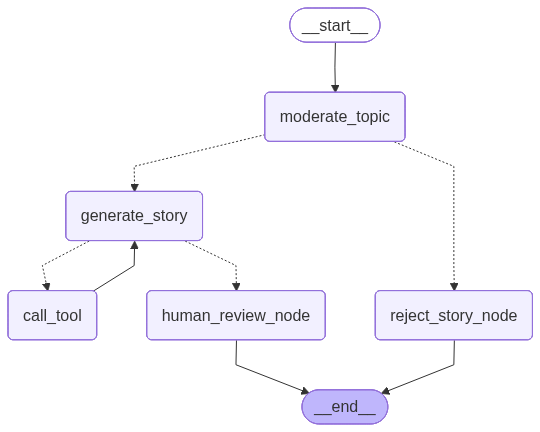

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [10]:
from langchain_core.messages import HumanMessage

input = {"messages": [HumanMessage(content="给我讲一个关于sharing的故事")]}
config = {"configurable": {"thread_id": "kid-story"}}
graph.invoke(input, config=config) # , stream_mode="updates"

{'messages': [HumanMessage(content='给我讲一个关于sharing的故事', additional_kwargs={}, response_metadata={}, id='f838dd84-32e8-4142-9fef-17292110f1ed'),
  AIMessage(content='我需要先检查您的问题是否涉及暴力、谋杀、性、毒品、死亡、血腥或战争这些主题。让我分析一下：\n\n您的问题是"给我讲一个关于sharing的故事"，主题是"sharing"（分享）。这个主题是关于分享、给予、合作等积极概念，与暴力、谋杀、性、毒品、死亡、血腥、战争这些负面主题没有直接关联。\n\n因此，返回：`false`', additional_kwargs={}, response_metadata={}, id='317e96ee-cbb8-4dab-958a-4198d85c99a9'),
  AIMessage(content='我来为您创作一个关于分享的故事：', additional_kwargs={'tool_calls': [{'id': 'call_00_ho0eGGZk5khFXC5YjeO1cpeu', 'function': {'arguments': '{"topic": "sharing"}', 'name': 'fetch_story'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 271, 'total_tokens': 294, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 128}, 'prompt_cache_hit_tokens': 128, 'prompt_cache_miss_tokens': 143}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281

In [11]:
graph.invoke(Command(resume={"action": "reject"}), config=config)

{'messages': [HumanMessage(content='给我讲一个关于sharing的故事', additional_kwargs={}, response_metadata={}, id='f838dd84-32e8-4142-9fef-17292110f1ed'),
  AIMessage(content='我需要先检查您的问题是否涉及暴力、谋杀、性、毒品、死亡、血腥或战争这些主题。让我分析一下：\n\n您的问题是"给我讲一个关于sharing的故事"，主题是"sharing"（分享）。这个主题是关于分享、给予、合作等积极概念，与暴力、谋杀、性、毒品、死亡、血腥、战争这些负面主题没有直接关联。\n\n因此，返回：`false`', additional_kwargs={}, response_metadata={}, id='317e96ee-cbb8-4dab-958a-4198d85c99a9'),
  AIMessage(content='我来为您创作一个关于分享的故事：', additional_kwargs={'tool_calls': [{'id': 'call_00_ho0eGGZk5khFXC5YjeO1cpeu', 'function': {'arguments': '{"topic": "sharing"}', 'name': 'fetch_story'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 271, 'total_tokens': 294, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 128}, 'prompt_cache_hit_tokens': 128, 'prompt_cache_miss_tokens': 143}, 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_ffc7281